In [1]:
# ── Imports ──
# Julio Rodriguez V2 changes vs V1:
#   - Added k_per_9: Julio makes contact and adjusts to pitchers — unlike Schwarber,
#     pitcher strikeout rate may genuinely shift his outcome distribution
import sys
sys.path.append("../scripts")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sqlalchemy import text
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score
from pybaseball import statcast_batter
from data_collection import engine


In [2]:
# ── Load base dataset from database ──
# Julio Rodriguez player_id = 677594
PLAYER_ID = 677594

with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            w.game_id,
            w.date,
            w.season,
            w.home_away,
            w.tb,
            w.hr,
            w.opponent_id,
            p.throws,
            p.era,
            p.k_per_9,
            pf.park_factor,
            pf.park_factor_hr
        FROM player_game_logs w
        JOIN pitcher_game_logs p ON w.game_id = p.game_id
        JOIN park_factors pf ON (
            CASE WHEN w.home_away = 'home' THEN 136
                 ELSE w.opponent_id
            END = pf.team_id
        )
        WHERE w.player_id = :pid
        ORDER BY w.date
    """), conn, params={"pid": PLAYER_ID})

print(f"Base dataset: {df.shape}")
print(df[['date', 'hr', 'tb', 'era']].head(10))


Base dataset: (603, 12)
         date  hr  tb   era
0  2022-04-08   0   0  4.20
1  2022-04-09   0   2  4.20
2  2022-04-10   0   0  4.20
3  2022-04-11   0   0  4.20
4  2022-04-13   0   0  4.20
5  2022-04-14   0   1  4.20
6  2022-04-15   0   1  4.50
7  2022-04-16   0   0  1.80
8  2022-04-17   0   1  1.80
9  2022-04-19   0   1  6.75


In [3]:
# ── HR distribution and base rate ──
print("HR distribution:")
print(df['hr'].value_counts().sort_index())

hr_rate = (df['hr'] >= 1).mean()
print(f"\nGames with 0 HR:  {(df['hr'] == 0).mean():.3f}")
print(f"Games with 1+ HR: {hr_rate:.3f} ({hr_rate*100:.1f}% of games)")
print(f"Games with 2+ HR: {(df['hr'] >= 2).mean():.3f}")

breakeven = -hr_rate / (1 - hr_rate) * 100
print(f"\nBreak-even American odds: {breakeven:.0f}")
print(f"\n(Witt: 16.0%, Henderson: 17.0% for comparison)")


HR distribution:
hr
0    498
1     98
2      7
Name: count, dtype: int64

Games with 0 HR:  0.826
Games with 1+ HR: 0.174 (17.4% of games)
Games with 2+ HR: 0.012

Break-even American odds: -21

(Witt: 16.0%, Henderson: 17.0% for comparison)


In [4]:
# ── Pull Statcast data via pybaseball ──
# Julio Rodriguez player_id = 677594
print("Pulling Statcast data...")
statcast_raw = statcast_batter('2022-04-01', '2025-10-01', player_id=677594)
print(f"Statcast raw: {statcast_raw.shape}")


Pulling Statcast data...
Gathering Player Data
Statcast raw: (10063, 118)


In [5]:
# ── Aggregate Statcast to game level ──
batted = statcast_raw[statcast_raw['launch_speed'].notna()].copy()

# HR zone: 25-35 degree launch angle band — where balls most frequently leave the park
batted['in_hr_zone'] = batted['launch_angle'].between(25, 35).astype(int)

game_stats = batted.groupby('game_date').agg(
    avg_exit_velo=('launch_speed', 'mean'),
    barrel_count=('launch_speed_angle', lambda x: (x == 6).sum()),
    hard_hit_count=('launch_speed', lambda x: (x >= 95).sum()),
    hr_zone_count=('in_hr_zone', 'sum'),
    batted_balls=('launch_speed', 'count'),
).reset_index()

game_stats['barrel_rate']   = game_stats['barrel_count']   / game_stats['batted_balls']
game_stats['hard_hit_rate'] = game_stats['hard_hit_count'] / game_stats['batted_balls']
game_stats['hr_zone_rate']  = game_stats['hr_zone_count']  / game_stats['batted_balls']

print(f"Game-level Statcast: {game_stats.shape}")
print(game_stats[['game_date', 'barrel_rate', 'hr_zone_rate']].head(10))

Game-level Statcast: (608, 9)
    game_date  barrel_rate  hr_zone_rate
0  2022-04-01          0.0      0.000000
1  2022-04-08          0.0      0.000000
2  2022-04-09          0.0      0.142857
3  2022-04-10          0.0      0.166667
4  2022-04-11          0.0      0.000000
5  2022-04-13          0.0      0.000000
6  2022-04-14          0.0      0.000000
7  2022-04-15          0.0      0.000000
8  2022-04-16          0.0      0.500000
9  2022-04-17          0.0      0.000000


In [6]:
# ── Rolling Statcast features — 15-day window ──
game_stats = game_stats.sort_values('game_date').reset_index(drop=True)

game_stats['avg_exit_velo_15'] = game_stats['avg_exit_velo'].shift(1).rolling(15, min_periods=7).mean()
game_stats['barrel_rate_15']   = game_stats['barrel_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hard_hit_rate_15'] = game_stats['hard_hit_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hr_zone_rate_15']  = game_stats['hr_zone_rate'].shift(1).rolling(15, min_periods=7).mean()

print(game_stats[['game_date', 'barrel_rate_15', 'hr_zone_rate_15']].head(20))

     game_date  barrel_rate_15  hr_zone_rate_15
0   2022-04-01             NaN              NaN
1   2022-04-08             NaN              NaN
2   2022-04-09             NaN              NaN
3   2022-04-10             NaN              NaN
4   2022-04-11             NaN              NaN
5   2022-04-13             NaN              NaN
6   2022-04-14             NaN              NaN
7   2022-04-15        0.000000         0.044218
8   2022-04-16        0.000000         0.038690
9   2022-04-17        0.000000         0.089947
10  2022-04-19        0.000000         0.080952
11  2022-04-20        0.000000         0.073593
12  2022-04-21        0.000000         0.067460
13  2022-04-22        0.000000         0.100733
14  2022-04-23        0.010204         0.093537
15  2022-04-24        0.022857         0.100635
16  2022-04-26        0.022857         0.100635
17  2022-04-27        0.022857         0.100635
18  2022-04-28        0.022857         0.104444
19  2022-04-29        0.022857         0

In [7]:
# ── Merge Statcast into base dataset ──
game_stats['game_date'] = pd.to_datetime(game_stats['game_date'])
df['date'] = pd.to_datetime(df['date'])

df = df.merge(
    game_stats[['game_date', 'avg_exit_velo_15', 'barrel_rate_15',
                'hard_hit_rate_15', 'hr_zone_rate_15']],
    left_on='date',
    right_on='game_date',
    how='left'
)

print(f"After merge: {df.shape}")
print(df[['avg_exit_velo_15', 'barrel_rate_15', 'hr_zone_rate_15']].isnull().sum())

After merge: (603, 17)
avg_exit_velo_15    23
barrel_rate_15      23
hr_zone_rate_15     23
dtype: int64


In [8]:
# ── Feature engineering ──
df = df.sort_values('date').reset_index(drop=True)

df['is_home']   = (df['home_away'] == 'home').astype(int)
df['pitcher_r'] = (df['throws'] == 'R').astype(int)

# Julio bats right — pitcher_r direction uncertain vs Witt
# T-Mobile Park is pitcher-friendly (91) — road games in hitter parks
# should show stronger park_factor signal than for players in neutral parks

# Drop rows missing Statcast rolling features only
df_model = df.dropna(subset=['avg_exit_velo_15', 'barrel_rate_15',
                              'hr_zone_rate_15']).reset_index(drop=True)

print(f"Model dataset: {df_model.shape}")


Model dataset: (580, 19)


In [9]:
# ── Define features and binary target ──
# Julio V2 — 9 features, added k_per_9
# k_per_9 hypothesis: Julio adjusts approach based on pitcher profile —
#   high K/9 pitcher may suppress his HR rate unlike Schwarber who swings regardless
FEATURES = [
    # Julio contact quality
    'avg_exit_velo_15',
    'barrel_rate_15',
    'hard_hit_rate_15',
    'hr_zone_rate_15',
    # Game context
    'is_home',
    'pitcher_r',
    # Pitcher
    'era',
    'k_per_9',
    # Park
    'park_factor',
]

X = df_model[FEATURES]
y_binary = (df_model['hr'] >= 1).astype(int)

print(f"Features: {len(FEATURES)}")
print(f"Dataset: {X.shape}")
print(f"HR rate: {y_binary.mean():.3f} ({y_binary.sum()} HR games out of {len(y_binary)})")
print(f"\n(Witt: 0.160, Henderson: 0.170 for comparison)")


Features: 9
Dataset: (580, 9)
HR rate: 0.181 (105 HR games out of 580)

(Witt: 0.160, Henderson: 0.170 for comparison)


In [10]:
# ── Scale features ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

In [11]:
# ── Baseline ──
baseline_acc = 1 - y_binary.mean()
print(f"Baseline accuracy (always predict no HR): {baseline_acc:.3f}")
breakeven = -y_binary.mean() / (1 - y_binary.mean()) * 100
print(f"Break-even odds for HR prop: {breakeven:.0f}")

Baseline accuracy (always predict no HR): 0.819
Break-even odds for HR prop: -22


In [12]:
# ── Regularization tuning — grid search over C ──
# C controls regularization strength
# Low C = stronger regularization = simpler model, less overfit
# High C = weaker regularization = fits training data more closely
C_grid = [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    LogisticRegression(max_iter=500),
    param_grid={'C': C_grid},
    cv=tscv,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1
)

grid_search.fit(X_scaled, y_binary)

best_C   = grid_search.best_params_['C']
best_auc = grid_search.best_score_

print(f"Best C:        {best_C}")
print(f"Best CV AUC:   {best_auc:.3f}")
print()

results = pd.DataFrame(grid_search.cv_results_)
print(results[['param_C', 'mean_test_score', 'std_test_score']].round(4).to_string(index=False))

Best C:        0.001
Best CV AUC:   0.556

 param_C  mean_test_score  std_test_score
   0.001           0.5559          0.0746
   0.010           0.5538          0.0698
   0.050           0.5494          0.0674
   0.100           0.5473          0.0647
   0.250           0.5422          0.0624
   0.500           0.5379          0.0613
   1.000           0.5353          0.0629
   2.000           0.5348          0.0636
   5.000           0.5337          0.0643
  10.000           0.5328          0.0637


In [13]:
# ── Cross-validation with best C ──
model = grid_search.best_estimator_

cv_auc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='roc_auc')
cv_acc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='accuracy')

print(f"CV AUC per fold:  {[round(v,3) for v in cv_auc]}")
print(f"CV ACC per fold:  {[round(v,3) for v in cv_acc]}")
print(f"\nAUC mean +/- std: {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")
print(f"ACC mean +/- std: {cv_acc.mean():.3f} +/- {cv_acc.std():.3f}")
print(f"\nBaseline ACC:     {baseline_acc:.3f}")
print(f"Improvement:      {cv_acc.mean() - baseline_acc:.3f}")
print(f"\nJulio V1 CV AUC: 0.555  (no k_per_9)")
print(f"Julio V2 CV AUC: {cv_auc.mean():.3f}  (with k_per_9)")
print(f"Witt V10 CV AUC: 0.567")
print(f"\n(AUC > 0.55 = meaningful signal for sports betting)")


CV AUC per fold:  [np.float64(0.513), np.float64(0.582), np.float64(0.585), np.float64(0.439), np.float64(0.66)]
CV ACC per fold:  [np.float64(0.802), np.float64(0.812), np.float64(0.885), np.float64(0.812), np.float64(0.802)]

AUC mean +/- std: 0.556 +/- 0.075
ACC mean +/- std: 0.823 +/- 0.032

Baseline ACC:     0.819
Improvement:      0.004

Julio V1 CV AUC: 0.555  (no k_per_9)
Julio V2 CV AUC: 0.556  (with k_per_9)
Witt V10 CV AUC: 0.567

(AUC > 0.55 = meaningful signal for sports betting)


In [14]:
# ── Fit on full dataset ──
model.fit(X_scaled, y_binary)
df_model['p_hr'] = model.predict_proba(X_scaled)[:, 1]

insample_auc = roc_auc_score(y_binary, df_model['p_hr'])
insample_acc = accuracy_score(y_binary, model.predict(X_scaled))

print(f"In-sample AUC:  {insample_auc:.3f}")
print(f"In-sample ACC:  {insample_acc:.3f}")
print(f"CV AUC:         {cv_auc.mean():.3f}")
print(f"\nGap (in-sample - CV AUC): {insample_auc - cv_auc.mean():.3f}")
print("(smaller gap = less overfitting)")
print(f"\nMean P(HR):     {df_model['p_hr'].mean():.3f}")
print(f"Actual HR rate: {y_binary.mean():.3f}")

In-sample AUC:  0.598
In-sample ACC:  0.819
CV AUC:         0.556

Gap (in-sample - CV AUC): 0.042
(smaller gap = less overfitting)

Mean P(HR):     0.181
Actual HR rate: 0.181


In [15]:
# ── Calibration table ──
df_model['pred_bin'] = pd.qcut(df_model['p_hr'], q=5, labels=False)

calibration = df_model.groupby('pred_bin').agg(
    mean_predicted=('p_hr', 'mean'),
    actual_rate=('hr', lambda x: (x >= 1).mean()),
    n=('hr', 'count')
).round(3)

print(calibration)
spread = calibration['actual_rate'].iloc[-1] - calibration['actual_rate'].iloc[0]
print(f"\nSpread (bin 4 - bin 0): {spread:.3f}")
print(f"V6 spread:              0.185")
print(f"V5 spread:              ~0.12")
print("\n(larger spread = better discrimination between HR and non-HR games)")

          mean_predicted  actual_rate    n
pred_bin                                  
0                  0.173        0.121  116
1                  0.178        0.138  116
2                  0.181        0.181  116
3                  0.184        0.216  116
4                  0.189        0.250  116

Spread (bin 4 - bin 0): 0.129
V6 spread:              0.185
V5 spread:              ~0.12

(larger spread = better discrimination between HR and non-HR games)


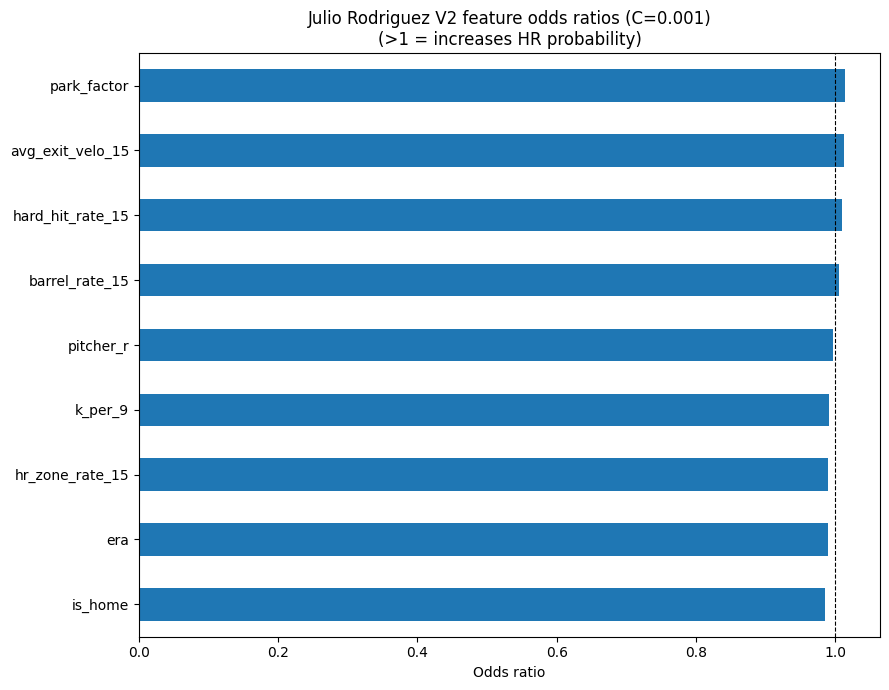


Odds ratios:
is_home             0.986
era                 0.990
hr_zone_rate_15     0.990
k_per_9             0.992
pitcher_r           0.996
barrel_rate_15      1.006
hard_hit_rate_15    1.009
avg_exit_velo_15    1.013
park_factor         1.014
dtype: float64


In [16]:
# ── Feature odds ratios ──
# Expected directions:
#   era        > 1 — higher ERA = worse pitcher = more HRs
#   k_per_9    < 1 — strikeout pitchers limit balls in play
#   park_factor > 1 — T-Mobile is 91, road games in hitter parks clearly better
#   pitcher_r  uncertain — Julio bats right
#   is_home    < 1 — T-Mobile suppresses HRs
coefs = pd.Series(model.coef_[0], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
np.exp(coefs).sort_values().plot(kind='barh', ax=ax)
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(f'Julio Rodriguez V2 feature odds ratios (C={best_C})\n(>1 = increases HR probability)')
ax.set_xlabel('Odds ratio')
plt.tight_layout()
plt.show()

print("\nOdds ratios:")
print(np.exp(coefs).round(3))


In [17]:
# ── Implied odds converter ──
def prob_to_american_odds(p):
    if p >= 0.5:
        return round(-p / (1 - p) * 100)
    else:
        return round((1 - p) / p * 100)

sample = df_model[['date', 'hr', 'p_hr']].copy()
sample['implied_odds'] = sample['p_hr'].apply(prob_to_american_odds)
sample['result'] = (sample['hr'] >= 1).map({True: '✅ HR', False: '❌ No HR'})

print("Last 20 games — model probability vs actual result:")
print(sample[['date', 'p_hr', 'implied_odds', 'result']].tail(20).to_string())

Last 20 games — model probability vs actual result:
          date      p_hr  implied_odds   result
560 2025-09-06  0.185239           440     ✅ HR
561 2025-09-07  0.187047           435  ❌ No HR
562 2025-09-08  0.178326           461  ❌ No HR
563 2025-09-09  0.179056           458  ❌ No HR
564 2025-09-10  0.178425           460  ❌ No HR
565 2025-09-11  0.177032           465  ❌ No HR
566 2025-09-12  0.178304           461  ❌ No HR
567 2025-09-13  0.181204           452  ❌ No HR
568 2025-09-14  0.178468           460  ❌ No HR
569 2025-09-16  0.185094           440  ❌ No HR
570 2025-09-17  0.180774           453  ❌ No HR
571 2025-09-18  0.187847           432  ❌ No HR
572 2025-09-19  0.187373           434     ✅ HR
573 2025-09-20  0.187457           433  ❌ No HR
574 2025-09-21  0.186679           436  ❌ No HR
575 2025-09-23  0.179691           457  ❌ No HR
576 2025-09-24  0.179073           458     ✅ HR
577 2025-09-25  0.180098           455  ❌ No HR
578 2025-09-26  0.179533           4

In [18]:
# ── Save model artifacts ──
joblib.dump(model,  '../models/julio_hr_logistic_v2_model.pkl')
joblib.dump(scaler, '../models/julio_hr_logistic_v2_scaler.pkl')
print("Saved:")
print("  models/julio_hr_logistic_v2_model.pkl")
print("  models/julio_hr_logistic_v2_scaler.pkl")
print(f"\nBest C: {best_C}")
print(f"Features ({len(FEATURES)}): {FEATURES}")


Saved:
  models/julio_hr_logistic_v2_model.pkl
  models/julio_hr_logistic_v2_scaler.pkl

Best C: 0.001
Features (9): ['avg_exit_velo_15', 'barrel_rate_15', 'hard_hit_rate_15', 'hr_zone_rate_15', 'is_home', 'pitcher_r', 'era', 'k_per_9', 'park_factor']
